<a href="https://colab.research.google.com/github/Zaynorang/uas-bigdata-ecommerce-segmentation-kelompok3/blob/main/BigdataProject_Kel3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# =====================================================================
# BAB 2.2: PROSES ETL - EXTRACT (EKSTRAKSI DATA)
# =====================================================================
import pandas as pd
import numpy as np
import kagglehub
from kagglehub import KaggleDatasetAdapter
from google.colab import drive

# 1. Mount Google Drive (Sesuai arsitektur untuk penyimpanan cloud berkapasitas tinggi)
drive.mount('/content/drive')

# 2. Extract Data via Kaggle API
dataset_handle = "limjeongeun/synthetic-u-s-e-commerce-dataset-1m-orders"
file_names = {
    'Customers': 'customers.csv',
    'Orders': 'orders.csv',
    'Order Items': 'order_items.csv',
    'Products': 'products.csv'
}

datasets = {}
print("⏳ Mengekstraksi dataset 1 juta baris menggunakan Kaggle API...")

for name, file_path in file_names.items():
    try:
        df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, dataset_handle, file_path)
        df.columns = df.columns.str.lower() # Seragamkan nama kolom
        datasets[name] = df
        print(f"✅ {name} diekstrak: {df.shape[0]:,} baris")
    except Exception as e:
        print(f"❌ Error ekstraksi '{file_path}': {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⏳ Mengekstraksi dataset 1 juta baris menggunakan Kaggle API...


/tmp/ipykernel_2231/4234052529.py:27: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, dataset_handle, file_path)


✅ Customers diekstrak: 1,000,000 baris


/tmp/ipykernel_2231/4234052529.py:27: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, dataset_handle, file_path)


Using Colab cache for faster access to the 'synthetic-u-s-e-commerce-dataset-1m-orders' dataset.
✅ Orders diekstrak: 1,000,000 baris


/tmp/ipykernel_2231/4234052529.py:27: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, dataset_handle, file_path)


Using Colab cache for faster access to the 'synthetic-u-s-e-commerce-dataset-1m-orders' dataset.
✅ Order Items diekstrak: 2,199,819 baris


/tmp/ipykernel_2231/4234052529.py:27: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, dataset_handle, file_path)


Using Colab cache for faster access to the 'synthetic-u-s-e-commerce-dataset-1m-orders' dataset.
✅ Products diekstrak: 2,000 baris


⏳ Memulai proses Transform (Pembersihan & Integrasi)...

📊 LAPORAN KUALITAS DATA (DATA QUALITY)
Total Data Mentah (Sebelum Cleansing): 2,199,819 baris
Total Baris Duplikat: 0 baris

Membuat grafik Missing Values...



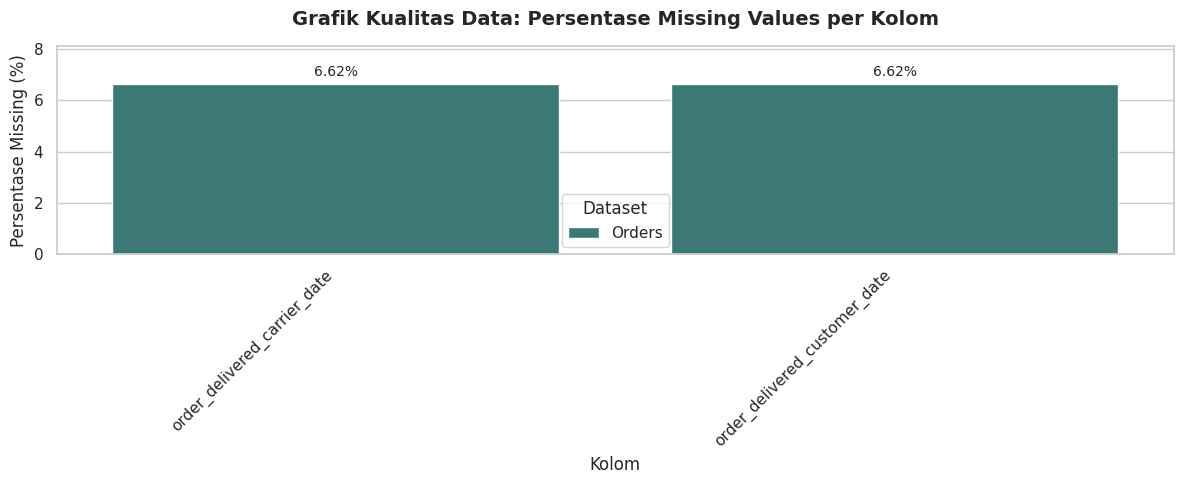


⏳ Melakukan Data Cleansing...
 ├── Missing values esensial dan duplikasi berhasil dihapus.
 ├── Fitur waktu dan finansial berhasil diekstrak.
✅ Transformasi selesai. Ukuran master_df (Sesudah Cleansing): 2,199,819 baris.
✅ Tahap Load selesai. Data bersih disimpan di: /content/drive/MyDrive/ecommerce_master_clean.parquet


In [9]:
# =====================================================================
# BAB 2.2: PROSES ETL - TRANSFORM & LOAD (DENGAN LAPORAN DATA QUALITY)
# =====================================================================
import gc
import pandas as pd

print("⏳ Memulai proses Transform (Pembersihan & Integrasi)...")

# 1. Penggabungan Data (Merge)
df_order_cust = pd.merge(datasets['Orders'], datasets['Customers'], on='customer_id', how='left')
df_items_prod = pd.merge(datasets['Order Items'], datasets['Products'], on='product_id', how='left')
master_df = pd.merge(df_items_prod, df_order_cust, on='order_id', how='left')

# Bebaskan RAM dari dataset mentah
del datasets, df_order_cust, df_items_prod
gc.collect()


# =====================================================================
# LAPORAN KUALITAS DATA (SEBELUM CLEANING) - VISUALISASI
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*50)
print("📊 LAPORAN KUALITAS DATA (DATA QUALITY)")
print("="*50)

# 1. Metrik Teks (Sebelum Cleansing)
initial_rows = master_df.shape[0]
print(f"Total Data Mentah (Sebelum Cleansing): {initial_rows:,} baris")

total_duplicates = master_df.duplicated().sum()
print(f"Total Baris Duplikat: {total_duplicates:,} baris\n")

# 2. Kalkulasi Missing Values
missing_pct = (master_df.isnull().sum() / initial_rows) * 100
missing_df = missing_pct[missing_pct > 0].reset_index()
missing_df.columns = ['Kolom', 'Persentase Missing (%)']

# 3. Membuat Visualisasi Grafik (Sesuai Referensi Gambar)
if not missing_df.empty:
    print("Membuat grafik Missing Values...\n")

    # Menambahkan label dataset untuk legend tiruan agar persis seperti gambar
    missing_df['Dataset'] = 'Orders'

    # Mengatur tema dan ukuran canvas
    plt.figure(figsize=(12, 5))
    sns.set_theme(style="whitegrid")

    # Membuat Barplot dengan warna khusus (Teal/Hijau Tosca)
    ax = sns.barplot(
        data=missing_df,
        x='Kolom',
        y='Persentase Missing (%)',
        hue='Dataset',
        palette=['#32827e'] # Kode warna yang mirip dengan foto
    )

    # Menambahkan Judul dan Label Aksis
    plt.title('Grafik Kualitas Data: Persentase Missing Values per Kolom', fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('Persentase Missing (%)', fontsize=12)
    plt.xlabel('Kolom', fontsize=12)
    plt.xticks(rotation=45, ha='right')

    # Menambahkan angka persentase (Anotasi) tepat di atas setiap diagram batang
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{p.get_height():.2f}%',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center',
                        xytext=(0, 9), textcoords='offset points', fontsize=10)

    # Memberikan sedikit ruang di atas grafik agar teks angka tidak terpotong
    plt.ylim(0, missing_df['Persentase Missing (%)'].max() + 1.5)

    # Merapikan layout dan menampilkannya
    plt.tight_layout()
    plt.show()
else:
    print(" - Tidak ada missing values yang signifikan untuk divisualisasikan!")

print("="*50 + "\n")

# =====================================================================
# 2. Transform: Penanganan Missing Values & Duplikasi
# =====================================================================
print("⏳ Melakukan Data Cleansing...")
master_df.drop_duplicates(inplace=True)

# Menghapus missing values HANYA pada primary key & kolom vital untuk K-Means
master_df.dropna(subset=['order_id', 'customer_unique_id', 'price_x'], inplace=True)
print(" ├── Missing values esensial dan duplikasi berhasil dihapus.")

# =====================================================================
# 3. Transform: Konversi Tipe Data & Rekayasa Fitur
# =====================================================================
master_df['order_purchase_timestamp'] = pd.to_datetime(master_df['order_purchase_timestamp'], errors='coerce')
master_df['Order_Year'] = master_df['order_purchase_timestamp'].dt.year
master_df['Order_Month'] = master_df['order_purchase_timestamp'].dt.month

master_df['Total_Amount'] = master_df['price_x']
master_df['quantity'] = 1
print(" ├── Fitur waktu dan finansial berhasil diekstrak.")

# =====================================================================
# 4. Transform: Downcasting (Optimasi RAM)
# =====================================================================
for col in master_df.select_dtypes(include=['float64']).columns:
    master_df[col] = pd.to_numeric(master_df[col], downcast='float')
for col in master_df.select_dtypes(include=['int64']).columns:
    master_df[col] = pd.to_numeric(master_df[col], downcast='integer')

final_rows = master_df.shape[0]
print(f"✅ Transformasi selesai. Ukuran master_df (Sesudah Cleansing): {final_rows:,} baris.")

# =====================================================================
# TAHAP LOAD (Ekspor ke Google Drive)
# =====================================================================
output_path = '/content/drive/MyDrive/ecommerce_master_clean.parquet'
master_df.to_parquet(output_path, index=False)
print(f"✅ Tahap Load selesai. Data bersih disimpan di: {output_path}")

📊 Memulai Exploratory Data Analysis (EDA)...


/tmp/ipykernel_2231/1742880877.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=master_df, x='Order_Month', palette='Blues_d', ax=ax1)


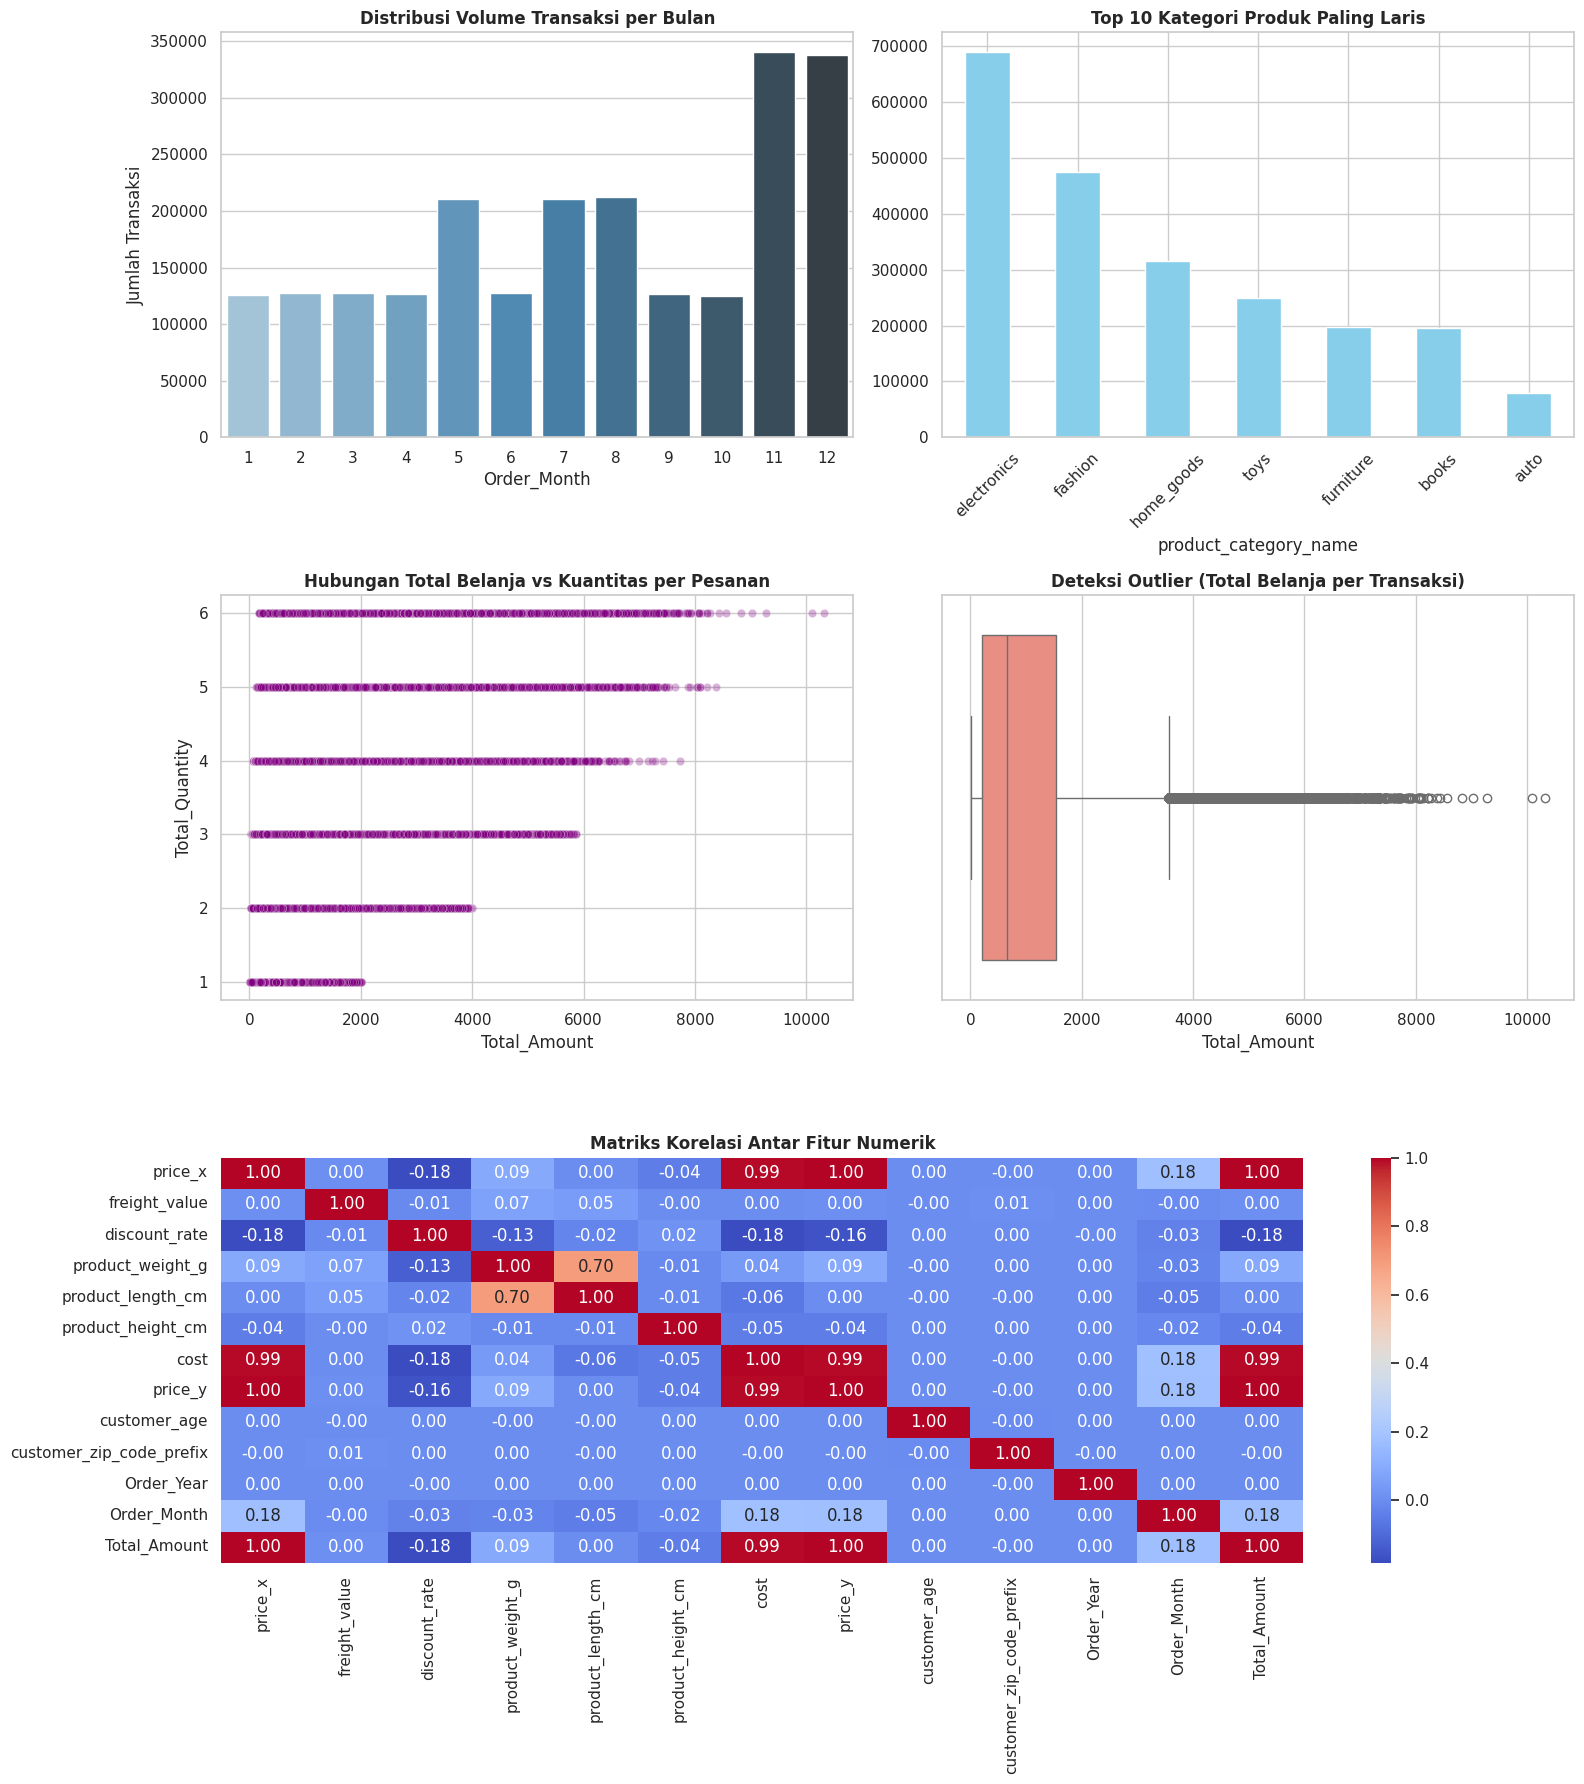

In [10]:
# =====================================================================
# BAB 2.3: EXPLORATORY DATA ANALYSIS (EDA)
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 Memulai Exploratory Data Analysis (EDA)...")

# Setup layout visualisasi (3 Baris, 2 Kolom)
fig = plt.figure(figsize=(16, 18))

# a. Analisis Univariat: Distribusi Volume Transaksi per Bulan
ax1 = plt.subplot(3, 2, 1)
sns.countplot(data=master_df, x='Order_Month', palette='Blues_d', ax=ax1)
ax1.set_title('Distribusi Volume Transaksi per Bulan', fontweight='bold')
ax1.set_ylabel('Jumlah Transaksi')

# b. Analisis Univariat: Kategori Produk Teratas
ax2 = plt.subplot(3, 2, 2)
if 'product_category_name' in master_df.columns:
    master_df['product_category_name'].value_counts().head(10).plot(kind='bar', color='skyblue', ax=ax2)
    ax2.set_title('Top 10 Kategori Produk Paling Laris', fontweight='bold')
    ax2.tick_params(axis='x', rotation=45)

# Siapkan data agregasi level pesanan untuk Bivariat
order_summary = master_df.groupby('order_id').agg(
    Total_Quantity=('order_item_id', 'count'),
    Total_Amount=('Total_Amount', 'sum')
).reset_index()

# c. Bivariat: Harga vs Kuantitas (Per Transaksi)
ax3 = plt.subplot(3, 2, 3)
sns.scatterplot(data=order_summary, x='Total_Amount', y='Total_Quantity', alpha=0.3, color='purple', ax=ax3)
ax3.set_title('Hubungan Total Belanja vs Kuantitas per Pesanan', fontweight='bold')

# d. Deteksi Pencilan: Boxplot Total Belanja
ax4 = plt.subplot(3, 2, 4)
sns.boxplot(x=order_summary['Total_Amount'], color='salmon', ax=ax4)
ax4.set_title('Deteksi Outlier (Total Belanja per Transaksi)', fontweight='bold')

# e. Multivariat: Matriks Korelasi (Heatmap)
ax5 = plt.subplot(3, 1, 3)
# Menghapus kolom ID dan juga kolom 'quantity' yang nilainya konstan
numeric_cols = master_df.select_dtypes(include=[np.number]).drop(
    columns=[col for col in master_df.columns if 'id' in col.lower()] + ['quantity'],
    errors='ignore'
)
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=ax5)
ax5.set_title('Matriks Korelasi Antar Fitur Numerik', fontweight='bold')

plt.tight_layout()
plt.show()

⚙️ Mempersiapkan data untuk Segmentasi Pelanggan (Customer Level)...
✅ Feature Scaling menggunakan StandardScaler selesai.
⏳ Menghitung WCSS untuk Elbow Method (k=1 hingga k=10)...


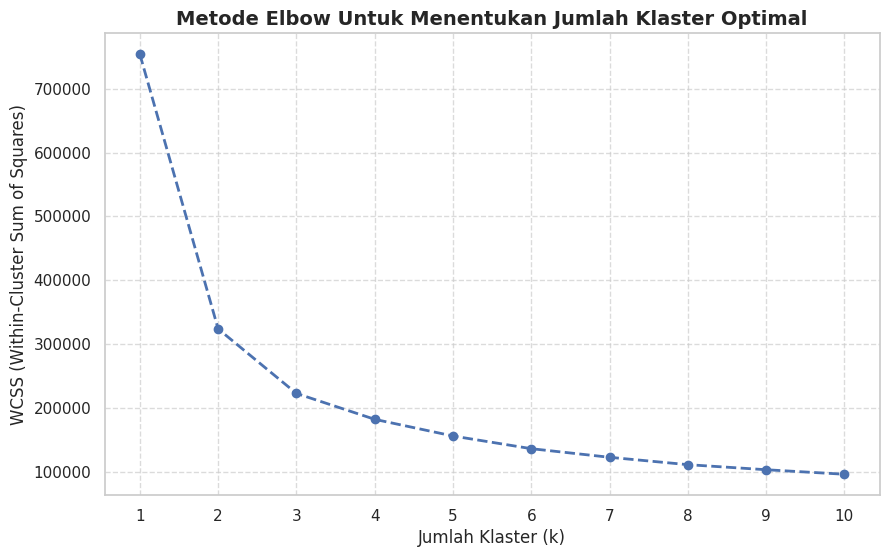


✅ Model K-Means berhasil dilatih dengan k=4.

Statistik Pusat Klaster (Centroid):
         Total_Belanja  Total_Barang_Dibeli  Frekuensi_Transaksi
Cluster                                                         
0          2857.330078                 6.86                 3.33
1          6677.620117                15.92                 7.04
2          5019.629883                10.46                 4.75
3          1337.800049                 3.40                 1.73


3411

In [11]:
# =====================================================================
# BAB 2.4: SKENARIO PEMODELAN & ALGORITMA (K-MEANS CLUSTERING)
# =====================================================================
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("⚙️ Mempersiapkan data untuk Segmentasi Pelanggan (Customer Level)...")

# 1. Feature Engineering Spesifik K-Means (RFM-like features)
customer_df = master_df.groupby('customer_unique_id').agg(
    Total_Belanja=('Total_Amount', 'sum'),           # Monetary
    Total_Barang_Dibeli=('order_item_id', 'count'),  # Quantity
    Frekuensi_Transaksi=('order_id', 'nunique')      # Frequency
).reset_index()

# Hapus outlier ekstrem agar centroid K-Means tidak bias
Q1 = customer_df['Total_Belanja'].quantile(0.05)
Q3 = customer_df['Total_Belanja'].quantile(0.95)
customer_df = customer_df[(customer_df['Total_Belanja'] >= Q1) & (customer_df['Total_Belanja'] <= Q3)]

# Pisahkan fitur untuk model
X = customer_df[['Total_Belanja', 'Total_Barang_Dibeli', 'Frekuensi_Transaksi']]

# 2. Feature Scaling (Sesuai metodologi: Standardisasi rentang nilai)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Feature Scaling menggunakan StandardScaler selesai.")

# 3. Evaluasi & Penentuan Jumlah Klaster (Elbow Method)
print("⏳ Menghitung WCSS untuk Elbow Method (k=1 hingga k=10)...")
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) # Menghitung inersia/WCSS

# Visualisasi Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, marker='o', linestyle='--', color='b', linewidth=2)
plt.title('Metode Elbow Untuk Menentukan Jumlah Klaster Optimal', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# =====================================================================
# PENERAPAN K-MEANS DENGAN NILAI K OPTIMAL
# =====================================================================
# Catatan: Ubah n_clusters sesuai dengan patahan grafik Elbow (misal k=4)
optimal_k = 4

final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=42)
customer_df['Cluster'] = final_kmeans.fit_predict(X_scaled)

print(f"\n✅ Model K-Means berhasil dilatih dengan k={optimal_k}.")
print("\nStatistik Pusat Klaster (Centroid):")
print(customer_df.groupby('Cluster')[['Total_Belanja', 'Total_Barang_Dibeli', 'Frekuensi_Transaksi']].mean().round(2))

# Membersihkan RAM terakhir
del master_df
gc.collect()

In [12]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print("\n" + "="*50)
print("📊 EVALUASI KINERJA MODEL K-MEANS")
print("="*50)

# Mengambil sampel data untuk Silhouette Score agar RAM tidak crash (Best Practice Big Data)
sample_size = min(20000, X_scaled.shape[0])
X_sample = X_scaled[:sample_size]
labels_sample = customer_df['Cluster'].values[:sample_size]

# Menghitung Metrik
print("⏳ Menghitung metrik evaluasi...")
sil_score = silhouette_score(X_sample, labels_sample, random_state=42)
db_index = davies_bouldin_score(X_scaled, customer_df['Cluster']) # DBI aman untuk full data
ch_index = calinski_harabasz_score(X_scaled, customer_df['Cluster']) # CH aman untuk full data

print(f"1. Silhouette Score         : {sil_score:.4f}")
print(f"2. Davies-Bouldin Index     : {db_index:.4f}")
print(f"3. Calinski-Harabasz Index  : {ch_index:.4f}")
print("="*50 + "\n")


📊 EVALUASI KINERJA MODEL K-MEANS
⏳ Menghitung metrik evaluasi...
1. Silhouette Score         : 0.3389
2. Davies-Bouldin Index     : 1.0496
3. Calinski-Harabasz Index  : 262597.5620

